In [17]:
# 1 Выполните сохранение монохромного изображения в виде текстового или бинарного файла.
# 2 Реализуйте алгоритм вейвлет-преобразования Хаара для изображения.
# 3 Выполните квантование высокочастотных компонент (прим., количество квантов = 4).
# 4 Сохраните получившийся массив значений в текстовый или бинарный файл в порядке LL, LH, HL, HH вейвлет-преобразования Хафа.
# Компоненты LH, HL, HH храните в виде пар (значение, количество повторений).
# Сравните объем памяти, занимаемый исходным изображением (попиксельное хранение), и изображение, полученным после преобразования Хафа и сжатием длин серий.

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import struct
import os

# 1 Выполните сохранение монохромного изображения в виде текстового или бинарного файла.

In [19]:
img = cv2.imread('sar_1.jpg', cv2.IMREAD_GRAYSCALE)
def save_image_bin(filename, data):
    with open(filename, 'wb') as f:
        f.write(struct.pack('I', data.shape[0]))  # Сохранение количества строк
        f.write(struct.pack('I', data.shape[1]))  # Сохранение количества столбцов
        f.write(data.tobytes())  # Сохранение данных изображения

def load_image_bin(filename):
    with open(filename, 'rb') as f:
        rows = struct.unpack('I', f.read(4))[0]  # Чтение количества строк
        cols = struct.unpack('I', f.read(4))[0]  # Чтение количества столбцов
        data = np.frombuffer(f.read(), dtype=np.uint8)  # Чтение данных изображения
        return data.reshape((rows, cols))  # Восстановление формы изображения
    
save_image_bin('image.bin', img)

# 2 Реализуйте алгоритм вейвлет-преобразования Хаара для изображения.

In [20]:
def haar_wavelet_1d(row):
    n = len(row)
    result = np.zeros(n, dtype=np.float32)
    
    result[:n//2] = (row[0::2] + row[1::2]) / 2  # L
    result[n//2:] = (row[0::2] - row[1::2]) / 2  # H
    
    return result

def haar_wavelet_2d(image):
    h, w = image.shape
    img = image.astype(np.float32)

    # 1. Преобразование по строкам
    temp = np.zeros_like(img)
    for i in range(h):
        temp[i] = haar_wavelet_1d(img[i])

    # 2. Преобразование по столбцам
    result = np.zeros_like(temp)
    for j in range(w):
        result[:, j] = haar_wavelet_1d(temp[:, j])

    # 3. Разбиение на LL, LH, HL, HH
    h2, w2 = h // 2, w // 2

    LL = result[:h2, :w2]
    LH = result[:h2, w2:]
    HL = result[h2:, :w2]
    HH = result[h2:, w2:]

    return LL, LH, HL, HH


LL, LH, HL, HH = haar_wavelet_2d(img)

# 3 Выполните квантование высокочастотных компонент (прим., количество квантов = 4).

In [21]:
quants = 4
def quantize(data, quants_value):
    dmin, dmax = np.min(data), np.max(data)

    if dmax == dmin:
        return np.zeros_like(data, dtype=np.int32), dmin, 1.0

    step = (dmax - dmin) / (quants_value - 1)

    q = np.round((data - dmin) / step)
    q = np.clip(q, 0, quants_value - 1).astype(np.int32)

    return q, dmin, step

q_LH, dmin_LH, step_LH = quantize(LH, quants)
q_HL, dmin_HL, step_HL = quantize(HL, quants)
q_HH, dmin_HH, step_HH = quantize(HH, quants)

# 4 Сохраните получившийся массив значений в текстовый или бинарный файл в порядке LL, LH, HL, HH вейвлет-преобразования Хафа.
# Компоненты LH, HL, HH храните в виде пар (значение, количество повторений).

In [22]:
def threshold_coeffs(arr, keep_percent=0.1):
    arr = arr.copy()
    mag = np.abs(arr)
    threshold = np.percentile(mag, 100 - keep_percent)
    arr[mag < threshold] = 0
    return arr, threshold

def rle(data):
    flat = np.ravel(data)

    if flat.size == 0:
        return []

    encoded = []
    prev = flat[0]
    count = 1

    for value in flat[1:]:
        if value == prev:
            count += 1
        else:
            encoded.append((prev, count))
            prev = value
            count = 1

    encoded.append((prev, count))
    return encoded

thresholded_LH, _ = threshold_coeffs(q_LH)
thresholded_HL, _ = threshold_coeffs(q_HL)
thresholded_HH, _ = threshold_coeffs(q_HH)

encoded_LH = rle(thresholded_LH)
encoded_HL = rle(thresholded_HL)
encoded_HH = rle(thresholded_HH)

def save_compressed(filename, LL, encoded_LH, encoded_HL, encoded_HH, dmin_LH, step_LH, dmin_HL, step_HL, dmin_HH, step_HH):
    with open(filename, 'wb') as f:
        f.write(struct.pack('I', LL.shape[0]))  # Сохранение количества строк LL
        f.write(struct.pack('I', LL.shape[1]))  # Сохранение количества столбцов LL
        f.write(LL.astype(np.float32).tobytes())  # Сохранение данных LL
        
        for encoded in [encoded_LH, encoded_HL, encoded_HH]:
            f.write(struct.pack('I', len(encoded)))  # Сохранение количества пар (value, count)
            for value, count in encoded:
                f.write(struct.pack('<BI', value, count))  # Сохранение пары (value, count)
        
        f.write(struct.pack('f', dmin_LH))  # Сохранение dmin для LH
        f.write(struct.pack('f', step_LH))   # Сохранение step для LH
        f.write(struct.pack('f', dmin_HL))  # Сохранение dmin для HL
        f.write(struct.pack('f', step_HL))   # Сохранение step для HL
        f.write(struct.pack('f', dmin_HH))  # Сохранение dmin для HH
        f.write(struct.pack('f', step_HH))   # Сохранение step для HH

def load_compressed(filename):
        with open(filename, 'rb') as f:
            rows = struct.unpack('I', f.read(4))[0]
            cols = struct.unpack('I', f.read(4))[0]
            LL = np.frombuffer(f.read(rows * cols * 4), dtype=np.float32).reshape((rows, cols))
            
            encoded_LH = []
            encoded_HL = []
            encoded_HH = []
            
            for encoded in [encoded_LH, encoded_HL, encoded_HH]:
                length = struct.unpack('I', f.read(4))[0]
                for _ in range(length):
                    value, count = struct.unpack('<BI', f.read(5))
                    encoded.append((value, count))
            
            dmin_LH = struct.unpack('f', f.read(4))[0]
            step_LH = struct.unpack('f', f.read(4))[0]
            dmin_HL = struct.unpack('f', f.read(4))[0]
            step_HL = struct.unpack('f', f.read(4))[0]
            dmin_HH = struct.unpack('f', f.read(4))[0]
            step_HH = struct.unpack('f', f.read(4))[0]
            
            return LL, encoded_LH, encoded_HL, encoded_HH, dmin_LH, step_LH, dmin_HL, step_HL, dmin_HH, step_HH

save_compressed('compressed.bin', LL, encoded_LH, encoded_HL, encoded_HH,
                dmin_LH, step_LH,
                dmin_HL, step_HL,
                dmin_HH, step_HH)




# Сравните объем памяти, занимаемый исходным изображением (попиксельное хранение), и изображение, полученным после преобразования Хафа и сжатием длин серий.

In [23]:
orig_size = os.path.getsize('image.bin')
compressed_size = os.path.getsize('compressed.bin')
print(f"Original size: {orig_size} bytes")
print(f"Compressed size: {compressed_size} bytes")
print(f"Compression ratio: {orig_size / compressed_size:.2f}")

Original size: 120008 bytes
Compressed size: 168764 bytes
Compression ratio: 0.71


Без квантования LL результат сжатия будет больше чем исходник, добиться текущего увеличения размера "всего" в 1.5 раза удалось только занулением 99.9% коэффицентов в LH HH HL, чтобы были длинные серии нулей

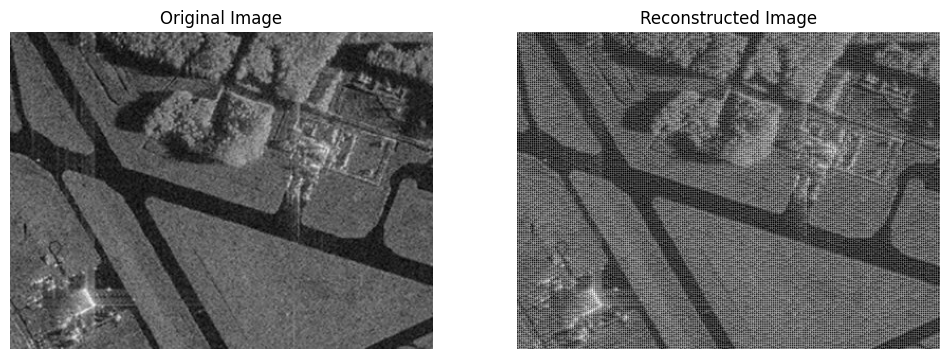

In [24]:
orig_img = load_image_bin('image.bin')
loaded_LL, loaded_encoded_LH, loaded_encoded_HL, loaded_encoded_HH, loaded_dmin_LH, loaded_step_LH, loaded_dmin_HL, loaded_step_HL, loaded_dmin_HH, loaded_step_HH = load_compressed('compressed.bin')

def decode_rle(encoded):
    decoded = []
    for value, count in encoded:
        decoded.extend([value] * count)
    return np.array(decoded)

def decode_quantized(q, dmin, step):
    return q * step + dmin

decoded_LH = decode_quantized(decode_rle(loaded_encoded_LH), loaded_dmin_LH, loaded_step_LH)
decoded_HL = decode_quantized(decode_rle(loaded_encoded_HL), loaded_dmin_HL, loaded_step_HL)
decoded_HH = decode_quantized(decode_rle(loaded_encoded_HH), loaded_dmin_HH, loaded_step_HH)

def inverse_haar_wavelet_2d(LL, LH, HL, HH):
    h2, w2 = LL.shape
    h, w = h2 * 2, w2 * 2

    # 1. Восстановление промежуточного массива после обратного преобразования по столбцам
    temp = np.zeros((h, w), dtype=np.float32)
    temp[:h2, :w2] = LL
    temp[:h2, w2:] = LH
    temp[h2:, :w2] = HL
    temp[h2:, w2:] = HH

    # 2. Обратное преобразование по столбцам
    result = np.zeros_like(temp)
    for j in range(w):
        result[:, j] = inverse_haar_wavelet_1d(temp[:, j])

    # 3. Обратное преобразование по строкам
    final_img = np.zeros_like(result)
    for i in range(h):
        final_img[i] = inverse_haar_wavelet_1d(result[i])

    return final_img

def inverse_haar_wavelet_1d(row):
    n = len(row)
    result = np.zeros(n, dtype=np.float32)
    
    result[0::2] = row[:n//2] + row[n//2:]  # L + H
    result[1::2] = row[:n//2] - row[n//2:]  # L - H
    
    return result

h2, w2 = loaded_LL.shape

decoded_LH = decode_quantized(
    decode_rle(loaded_encoded_LH).reshape((h2, w2)),
    loaded_dmin_LH, loaded_step_LH
)

decoded_HL = decode_quantized(
    decode_rle(loaded_encoded_HL).reshape((h2, w2)),
    loaded_dmin_HL, loaded_step_HL
)

decoded_HH = decode_quantized(
    decode_rle(loaded_encoded_HH).reshape((h2, w2)),
    loaded_dmin_HH, loaded_step_HH
)

reconstructed_img = inverse_haar_wavelet_2d(loaded_LL, decoded_LH, decoded_HL, decoded_HH)
reconstructed_img = np.clip(reconstructed_img, 0, 255).astype(np.uint8)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(orig_img, cmap='gray')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.title('Reconstructed Image')
plt.imshow(reconstructed_img, cmap='gray')
plt.axis('off')
plt.show()